## 0 - Explore

- based on amazon ESCI dataset real data of queries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data = pd.read_parquet('ds/shopping_queries_dataset_examples.parquet')

In [10]:
#data info

print(f"shape: {data.shape}")
print()
print(data.dtypes)

shape: (2621288, 9)

example_id         int64
query             object
query_id           int64
product_id        object
product_locale    object
esci_label        object
small_version      int64
large_version      int64
split             object
dtype: object


In [ ]:
data.info()

#example_id , query_id just ids no need
#query since we will focus on this instead of categorising with product dataset
#esci label already categorised by amazon (exact the query got exact result search , substitute similar , irrelevant)

#large small version split just to take the data you want
#locale es us jp

<class 'pandas.DataFrame'>
Index: 2621288 entries, 0 to 0
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   example_id      int64 
 1   query           object
 2   query_id        int64 
 3   product_id      object
 4   product_locale  object
 5   esci_label      object
 6   small_version   int64 
 7   large_version   int64 
 8   split           object
dtypes: int64(4), object(5)
memory usage: 200.0+ MB


In [ ]:
data[data['product_locale'] == 'es'][0:10]
#there is duplicate we shoul use random state or remove duplicate

,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,split
0,70,!solid camiseta sin manga,3,B08TQH4RBB,es,E,1,1,train
0,71,!solid camiseta sin manga,3,B08H2H18DN,es,E,1,1,train
0,72,!solid camiseta sin manga,3,B08HJQJT2T,es,E,1,1,train
0,73,!solid camiseta sin manga,3,B08LP68XTS,es,S,1,1,train
0,74,!solid camiseta sin manga,3,B08NDS1HS2,es,E,1,1,train
0,75,!solid camiseta sin manga,3,B08PNZHW6T,es,S,1,1,train
0,76,!solid camiseta sin manga,3,B08TQF34WG,es,I,1,1,train
0,77,!solid camiseta sin manga,3,B08TR31689,es,E,1,1,train
0,78,!solid camiseta sin manga,3,B0983KNTQX,es,E,1,1,train
0,79,!solid camiseta sin manga,3,B08ZC4CHDH,es,S,1,1,train


In [13]:
#null values
data.isnull().sum()

example_id        0
query             0
query_id          0
product_id        0
product_locale    0
esci_label        0
small_version     0
large_version     0
split             0
dtype: int64

In [14]:
data.describe().round(2)

,example_id,query_id,small_version,large_version
count,2621288.00,2621288.00,2621288.00,2621288.0
mean,1310643.50,66320.69,0.43,1.0
std,756700.81,38830.77,0.49,0.0
min,0.00,0.00,0.00,1.0
25%,655321.75,32525.75,0.00,1.0
50%,1310643.50,66479.00,0.00,1.0
75%,1965965.25,100616.00,1.00,1.0
max,2621287.00,130651.00,1.00,1.0


In [15]:
data.head(2)

,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,split
0,0,revent 80 cfm,0,B000MOO21W,us,I,0,1,train
0,1,revent 80 cfm,0,B07X3Y6B1V,us,E,0,1,train


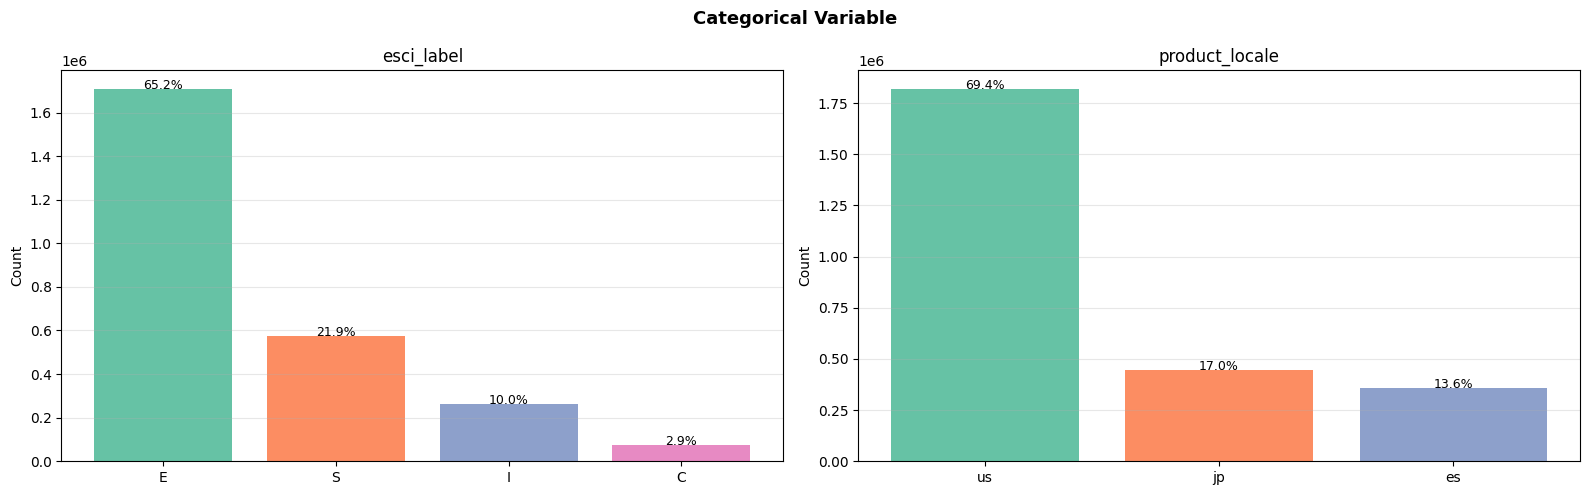

In [18]:
categ_cols = ['esci_label' , 'product_locale']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Categorical Variable', fontsize=13, fontweight='bold')

for ax, col in zip(axes, categ_cols):
    vc = data[col].value_counts()
    bars = ax.bar(vc.index, vc.values, color=sns.color_palette('Set2', len(vc)))
    ax.set_title(col)
    ax.set_ylabel('Count')
    for i, (idx, val) in enumerate(vc.items()):
        ax.text(i, val + 100, f'{val/len(data)*100:.1f}%', ha='center', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()